In [10]:
#  Core Libraries
!pip install -q numpy pandas matplotlib tqdm

#  Audio Processing
!pip install -q librosa soundfile

#  Machine Learning + DL
!pip install -q tensorflow scikit-learn keras-tuner


# TODO: 
    - Add gradient accumulation for larger effective batch sizes if needed.

In [11]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm


# === Constants ===
SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
SEED = 42
np.random.seed(SEED)

# === Paths ===
BASE_DIR = "/kaggle/working/"
AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Train"
CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Train.csv"
CACHE_DIR = os.path.join(BASE_DIR, "mel_cache")

# Make cache dir
os.makedirs(CACHE_DIR, exist_ok=True)

# === Load metadata
df = pd.read_csv(CSV_PATH)
df["filepath"] = df["file_name"].apply(lambda x: os.path.join(AUDIO_DIR, x))
df.head()


,file_name,classID,filepath
0,data_0.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...
1,data_1.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...
2,data_2.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...
3,data_3.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...
4,data_4.wav,6,/kaggle/input/yldz-teknik-proje-1-train-datase...


In [12]:
def mel_cache_audio(df, filepath_col="filepath", add_to_df=True):
    """
    Caches mel spectrograms for each file in the dataframe.
    Skips if already cached. Optionally adds 'mel_path' column to df.
    
    Enhancements:
    - Logs with tqdm.write() to avoid breaking progress bar
    - Checks if file exists before attempting to load
    - Verifies sample rate matches SR
    - Optionally updates DataFrame with path to cached mel file
    """
    created, skipped, failed = 0, 0, 0
    mel_paths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="📦 Caching mel spectrograms"):
        wav_path = row[filepath_col]
        out_path = os.path.join(CACHE_DIR, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(out_path)

        # Skip if already cached
        if os.path.exists(out_path):
            skipped += 1
            continue

        # Check if file exists
        if not os.path.exists(wav_path):
            tqdm.write(f"[ Missing] {wav_path}")
            failed += 1
            continue

        try:
            y, sr = librosa.load(wav_path, sr=SR)
            if sr != SR:
                tqdm.write(f"[ SR mismatch] {wav_path} → sr={sr}, expected {SR}")
            
            # Generate mel spectrogram
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)

            np.save(out_path, mel_db)
            created += 1

        except Exception as e:
            tqdm.write(f"[ Error] Skipping {wav_path}: {e}")
            failed += 1

    tqdm.write(f"\n Done. Created: {created}, Skipped: {skipped}, Failed: {failed}")

    if add_to_df:
        df["mel_path"] = mel_paths

    return df if add_to_df else None


In [13]:
df = mel_cache_audio(df)
df.head()

📦 Caching mel spectrograms: 100%|██████████| 7057/7057 [00:00<00:00, 17073.61it/s]


 Done. Created: 0, Skipped: 7057, Failed: 0


,file_name,classID,filepath,mel_path
0,data_0.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_0_mel.npy
1,data_1.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_1_mel.npy
2,data_2.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_2_mel.npy
3,data_3.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_3_mel.npy
4,data_4.wav,6,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_4_mel.npy


In [5]:
def inspect_cached_mels(df, n=5):
    print(f"\n📂 Inspecting {n} random cached mels:")
    sample_files = df.sample(n, random_state=np.random.randint(9999))
    
    for _, row in sample_files.iterrows():
        mel_path = os.path.join(
            CACHE_DIR, os.path.basename(row["filepath"]).replace(".wav", "_mel.npy")
        )
        try:
            mel = np.load(mel_path)
            print(f"✅ {mel_path}")
            print(f"  - Shape     : {mel.shape}")
            print(f"  - Min/Max   : {mel.min():.3f} / {mel.max():.3f}")
            print(f"  - Nonzero % : {np.count_nonzero(mel) / mel.size * 100:.2f}%")
        except Exception as e:
            print(f"❌ {mel_path} failed to load: {e}")


In [6]:
inspect_cached_mels(df)


📂 Inspecting 5 random cached mels:
✅ /kaggle/working/mel_cache/data_4218_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_2661_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_318_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_6731_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_5493_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%


In [14]:
import tensorflow as tf
import tensorflow_probability as tfp

@tf.function
def tf_augment_mel(mel):
    """Apply stronger data augmentation to a mel spectrogram (shape: [H, W, 1])"""
    shape = tf.shape(mel)
    height, width = shape[0], shape[1]
    x = mel

    # === Time Stretch ===
    if tf.random.uniform([]) < 0.5:
        stretch_factor = tf.random.uniform([], 0.8, 1.2)
        new_width = tf.cast(tf.cast(width, tf.float32) * stretch_factor, tf.int32)
        x = tf.image.resize(x, [height, new_width])
        x = tf.image.resize(x, [height, width])

    # === Time Mask ===
    if tf.random.uniform([]) < 0.7:
        mask_t = tf.cast(0.15 * tf.cast(width, tf.float32), tf.int32)
        t0 = tf.random.uniform([], 0, width - mask_t, dtype=tf.int32)
        time_mask = tf.pad(tf.ones([height, mask_t, 1]), [[0, 0], [t0, width - t0 - mask_t], [0, 0]])
        x = x * (1.0 - time_mask)

    # === Frequency Mask ===
    if tf.random.uniform([]) < 0.7:
        mask_f = tf.cast(0.15 * tf.cast(height, tf.float32), tf.int32)
        f0 = tf.random.uniform([], 0, height - mask_f, dtype=tf.int32)
        freq_mask = tf.pad(tf.ones([mask_f, width, 1]), [[f0, height - f0 - mask_f], [0, 0], [0, 0]])
        x = x * (1.0 - freq_mask)

    # === Add Gaussian Noise ===
    if tf.random.uniform([]) < 0.5:
        noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=0.01)
        x = x + noise

    # === Frequency Shift (roll vertically) ===
    if tf.random.uniform([]) < 0.5:
        shift_bins = tf.random.uniform([], -4, 4, dtype=tf.int32)
        x = tf.roll(x, shift=shift_bins, axis=0)

    # === Volume Jitter (brightness / loudness) ===
    if tf.random.uniform([]) < 0.8:
        volume_scale = tf.random.uniform([], 0.8, 1.2)
        x = x * volume_scale

    # === Clipping Simulation ===
    if tf.random.uniform([]) < 0.3:
        clip_val = tf.random.uniform([], 0.6, 0.95)
        x = tf.clip_by_value(x, 0.0, clip_val)

    # === Normalize ===
    x_min, x_max = tf.reduce_min(x), tf.reduce_max(x)
    x = (x - x_min) / (x_max - x_min + 1e-6)

    return x



## TODO: Turn this into a gpu op.
def mixup_batch(images, labels, num_classes, alpha=0.4):
    """
    Applies Mixup augmentation to a batch of images and labels.
    
    Args:
        images: Tensor of shape (B, H, W, C)
        labels: Tensor of shape (B,) — sparse integer labels
        num_classes: Total number of classes
        alpha: Beta distribution parameter for mixing strength

    Returns:
        Tuple of (mixed_images, mixed_labels) where labels are soft one-hot vectors.
    """
    batch_size = tf.shape(images)[0]

    # Sample lambda from symmetric Beta(α, α)
    lambda_val = tfp.distributions.Beta(alpha, alpha).sample([batch_size])
    lambda_val = tf.maximum(lambda_val, 1.0 - lambda_val)  # enforce stronger mixing (λ ≥ 0.5)

    # One-hot encode original labels
    labels_onehot = tf.one_hot(labels, depth=num_classes)

    # Shuffle batch
    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_images = tf.gather(images, indices)
    shuffled_labels = tf.gather(labels_onehot, indices)

    # Reshape lambdas
    lambda_x = tf.reshape(lambda_val, [-1, 1, 1, 1])
    lambda_y = tf.reshape(lambda_val, [-1, 1])

    # Mix
    mixed_images = images * lambda_x + shuffled_images * (1.0 - lambda_x)
    mixed_labels = labels_onehot * lambda_y + shuffled_labels * (1.0 - lambda_y)

    return mixed_images, mixed_labels




def create_mel_dataset(file_paths, labels, batch_size=32,augment=False, mixup=False,num_classes=10, shuffle=True,return_onehot_labels=False):
    """
    Creates a tf.data.Dataset with optional augmentation and mixup.
    
    Args:
        file_paths: list/array of .npy mel paths
        labels: integer labels
        batch_size: size of each training batch
        augment: whether to apply mel augmentations
        mixup: whether to apply mixup to batches
        num_classes: total number of classes (for one-hot)
        shuffle: whether to shuffle samples

    Returns:
        tf.data.Dataset ready for training
    """
    def _load_mel(path, label):
        mel = tf.numpy_function(np.load, [path], tf.float32)
        mel.set_shape([256, 150, 1])
        if return_onehot_labels:
            label = tf.one_hot(label, num_classes)
        return mel, label

    def _maybe_augment(mel, label):
        mel = tf.cond(
            tf.random.uniform([]) < 0.7,
            lambda: tf_augment_mel(mel),
            lambda: mel
        )
        return mel, label

    def _apply_mixup(images, labels):
        return mixup_batch(images, labels, num_classes=num_classes)

    # === Dataset building ===
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(_load_mel, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    if augment:
        ds = ds.map(_maybe_augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    if mixup:
        ds = ds.map(_apply_mixup, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)



# Validate Augment + Data Loader

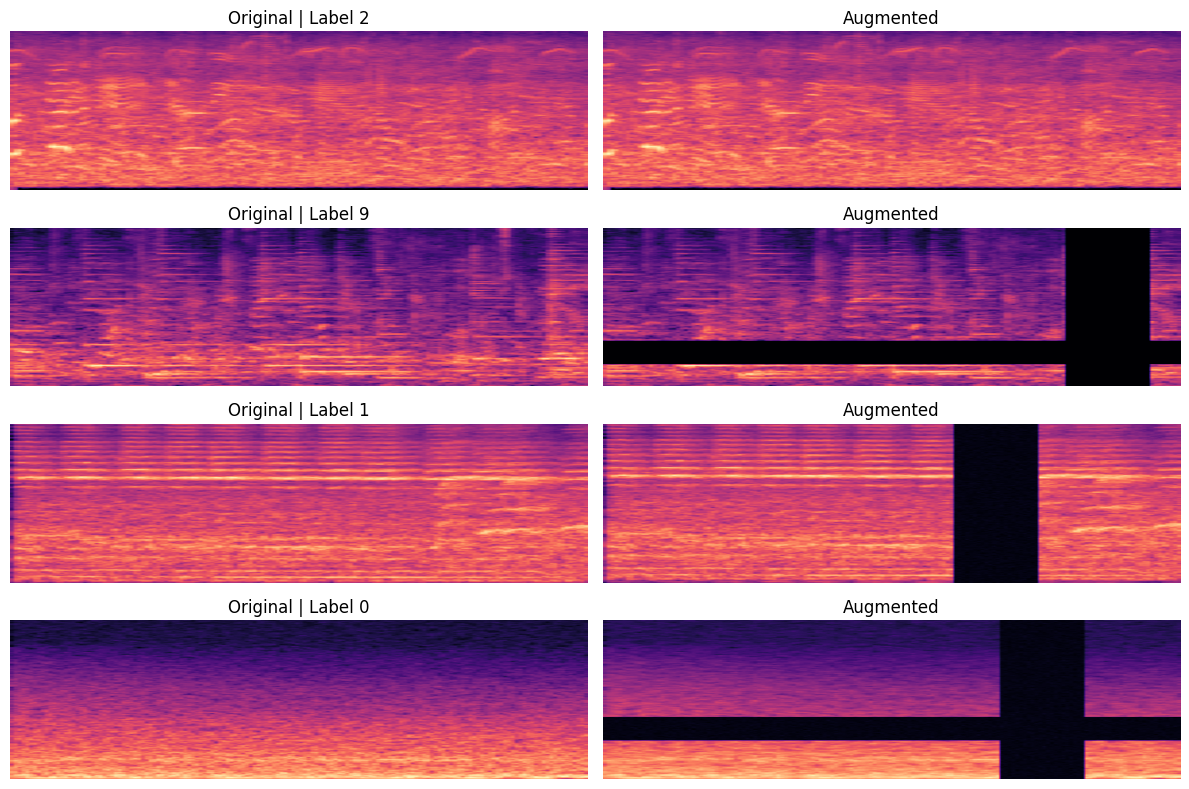

In [16]:
import matplotlib.pyplot as plt

# Sample some paths
sample_df = df.sample(4, random_state=np.random.randint(99999))
sample_paths = sample_df["mel_path"].values
sample_labels = sample_df["classID"].values

# Create two datasets (augmented and not)
ds_plain = create_mel_dataset(sample_paths, sample_labels, batch_size=4, augment=False, shuffle=False)
ds_aug = create_mel_dataset(sample_paths, sample_labels, batch_size=4, augment=True, shuffle=False)

# Load a batch from both
plain_batch = next(iter(ds_plain))
aug_batch = next(iter(ds_aug))

# Plot side-by-side
plt.figure(figsize=(12, 8))
for i in range(4):
    # Original
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(tf.squeeze(plain_batch[0][i]), cmap="magma", origin="lower", aspect="auto")
    plt.title(f"Original | Label {plain_batch[1][i].numpy()}")
    plt.axis("off")

    # Augmented
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(tf.squeeze(aug_batch[0][i]), cmap="magma", origin="lower", aspect="auto")
    plt.title(f"Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Validatign Mix Up and Data Loader

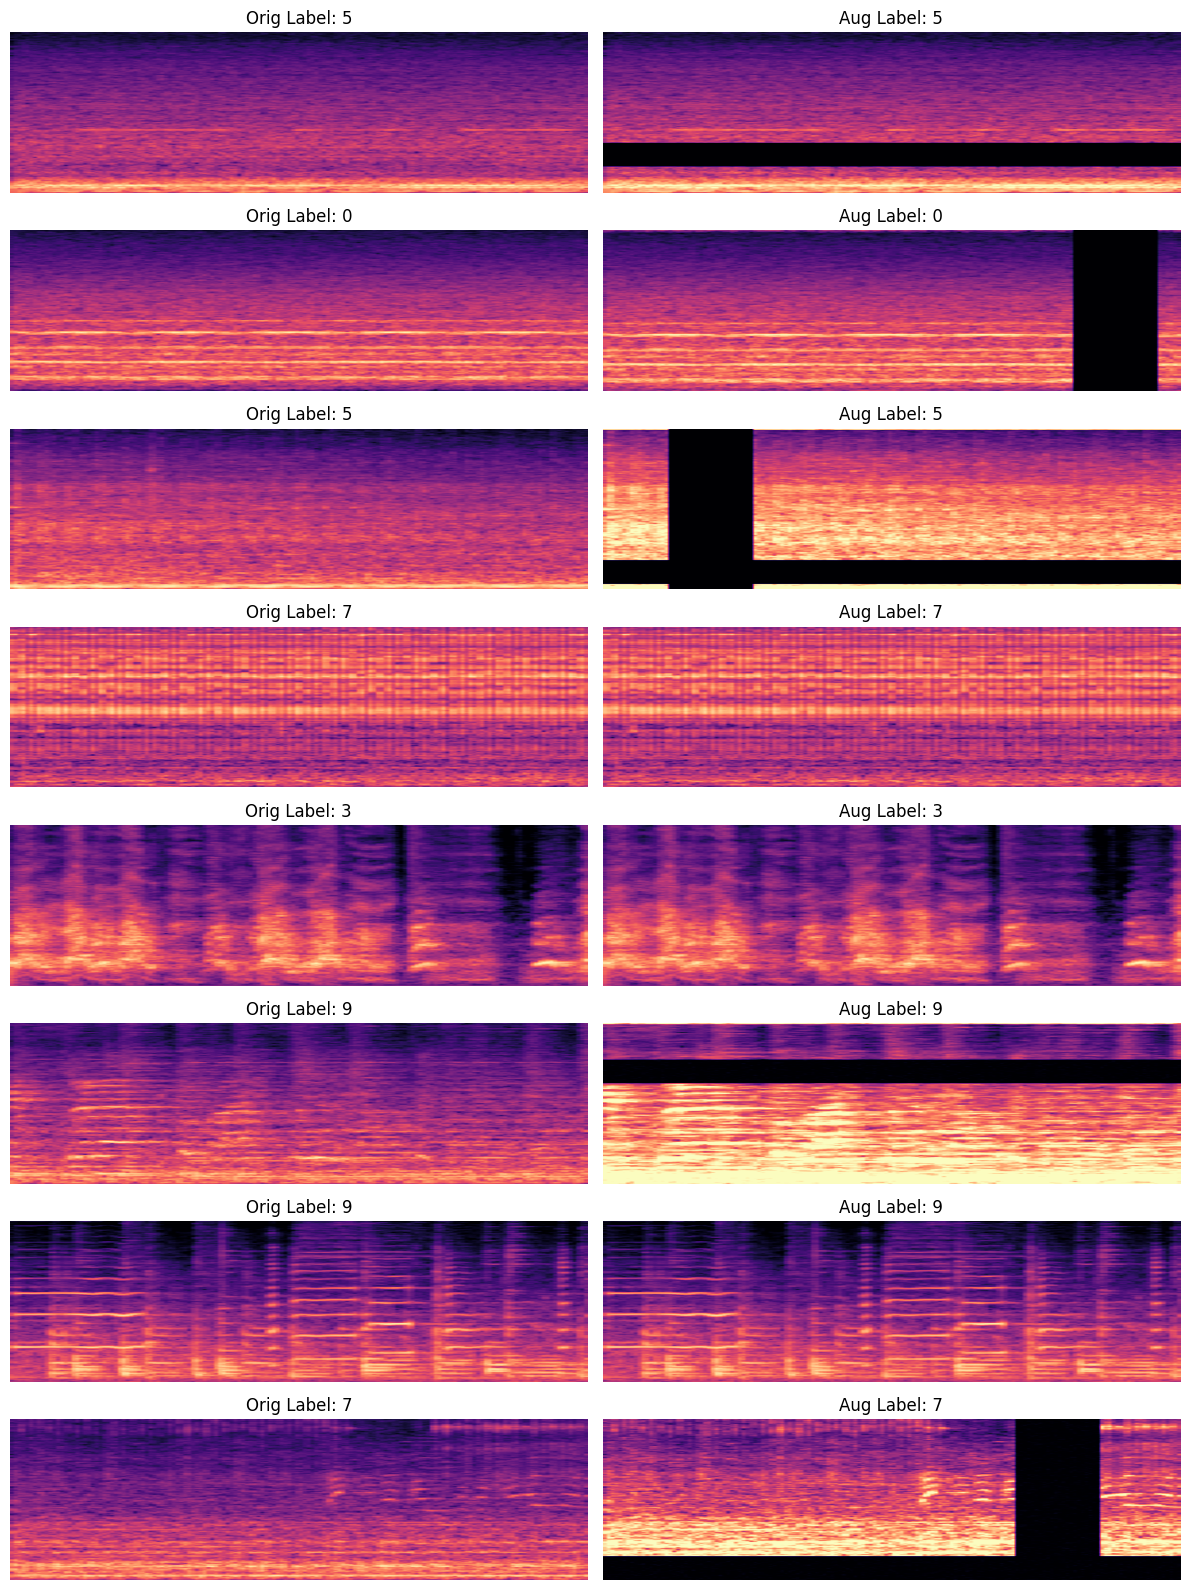

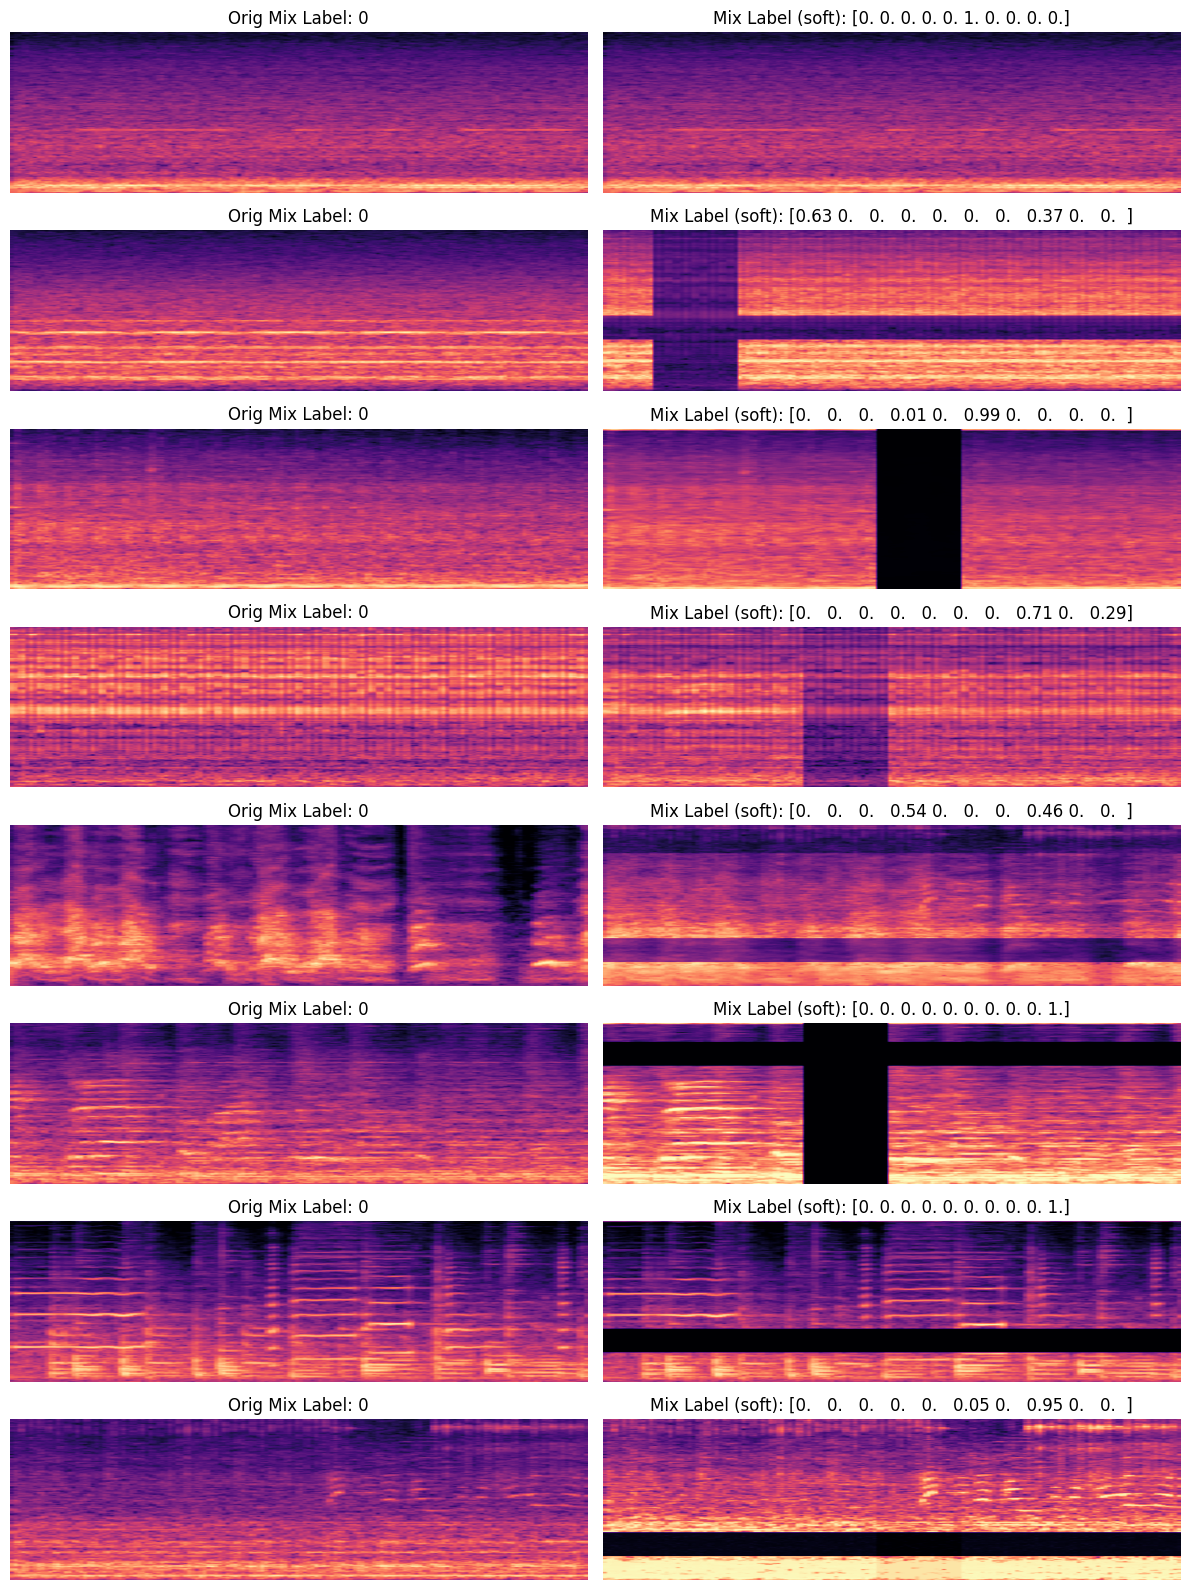

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# === Sample real data from df ===
sample_df = df.sample(8, random_state=np.random.randint(99999))
sample_paths = sample_df["mel_path"].values
sample_labels = sample_df["classID"].values

# === Create datasets ===
ds_plain = create_mel_dataset(sample_paths, sample_labels, batch_size=8, augment=False, mixup=False, shuffle=False)
ds_aug   = create_mel_dataset(sample_paths, sample_labels, batch_size=8, augment=True,  mixup=False, shuffle=False)
ds_mix   = create_mel_dataset(sample_paths, sample_labels, batch_size=8, augment=True,  mixup=True,  shuffle=False)

# === Visualization function ===
def visualize_pairwise(original_ds, aug_ds, is_mixup=False):
    mels_orig, labels_orig = next(iter(original_ds))
    mels_aug,  labels_aug  = next(iter(aug_ds))

    plt.figure(figsize=(12, 16))
    for i in range(len(mels_orig)):
        # Original
        plt.subplot(len(mels_orig), 2, 2*i + 1)
        plt.imshow(tf.squeeze(mels_orig[i]), aspect="auto", origin="lower", cmap="magma")
        if is_mixup:
            title = f"Orig Mix Label: {np.argmax(labels_orig[i])}"
        else:
            title = f"Orig Label: {int(labels_orig[i])}"
        plt.title(title)
        plt.axis("off")

        # Augmented / Mixup
        plt.subplot(len(mels_orig), 2, 2*i + 2)
        plt.imshow(tf.squeeze(mels_aug[i]), aspect="auto", origin="lower", cmap="magma")
        if is_mixup:
            title = f"Mix Label (soft): {np.round(labels_aug[i].numpy(), 2)}"
        else:
            title = f"Aug Label: {int(labels_aug[i])}"
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# === Show all ===
visualize_pairwise(ds_plain, ds_aug, is_mixup=False)
visualize_pairwise(ds_plain, ds_mix, is_mixup=True)


# Model Architecture

In [15]:
import tensorflow as tf

def attention_block(x, filters):
    """Applies both channel and spatial attention"""
    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(x)
    avg_pool = tf.keras.layers.Reshape((1, 1, filters))(avg_pool)
    avg_pool = tf.keras.layers.Conv2D(filters // 8, (1, 1), activation='relu')(avg_pool)
    avg_pool = tf.keras.layers.Conv2D(filters, (1, 1), activation='sigmoid')(avg_pool)
    x = tf.keras.layers.Multiply()([x, avg_pool])

    spatial = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
    x = tf.keras.layers.Multiply()([x, spatial])
    return x


def build_model(hp, mixup=False):
    """
    CNN model builder with optional attention and LR scheduling.
    If mixup=True, use categorical_crossentropy.
    """
    # === Tunable Hyperparams ===
    dropout_rate = hp.Float("dropout", 0.3, 0.6, step=0.1)
    l2_val = hp.Float("l2", 1e-5, 1e-3, sampling="log")
    filters_start = hp.Choice("filters_start", [32, 48, 64])
    depth = hp.Int("depth", 2, 4)
    use_attention = hp.Boolean("use_attention")
    pool_type = hp.Choice("pool_type", ["max", "avg"])
    lr_val = hp.Float("learning_rate", 1e-4, 1e-3, sampling="log")
    lr_schedule = hp.Choice("lr_schedule", ["none", "plateau", "cosine"])

    # === Input ===
    inputs = tf.keras.Input(shape=(256, 150, 1))
    x = inputs
    filters = filters_start

    for i in range(depth):
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same",
                                   kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same",
                                   kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        if pool_type == "max":
            x = tf.keras.layers.MaxPooling2D((2, 2))(x)
        else:
            x = tf.keras.layers.AveragePooling2D((2, 2))(x)

        filters *= 2

    if use_attention:
        x = attention_block(x, filters // 2)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    # === LR Schedule Setup ===
    if lr_schedule == "plateau":
        schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr_val,
            decay_steps=1000,
            decay_rate=0.9
        )
    elif lr_schedule == "cosine":
        schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=lr_val,
            decay_steps=1000
        )
    else:
        schedule = lr_val

    # === Loss Function ===
    loss_fn = 'categorical_crossentropy' if mixup else 'sparse_categorical_crossentropy'

    # === Final Compile ===
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=schedule),
        loss=loss_fn,
        metrics=['accuracy']
    )

    return model


# Hyperparameter Tuner - hyperband

In [16]:
import keras_tuner as kt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

def run_hyperparameter_tuning(file_paths, labels, max_epochs=20, factor=3,
                               hyperband_iterations=3, project_name="mel_tuning", use_mixup=True):
    """
    Runs Keras Tuner Hyperband with stratified split, class weights, and optional mixup.
    """
    # === Stratified Split ===
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, val_idx = next(sss.split(file_paths, labels))
    x_train, y_train = file_paths[train_idx], labels[train_idx]
    x_val, y_val = file_paths[val_idx], labels[val_idx]

    # === Compute Class Weights ===
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}
    print(f" Class Weights: {class_weight_dict}")

    # === Datasets ===
    train_ds = create_mel_dataset(x_train, y_train, augment=True, mixup=use_mixup)
    val_ds = create_mel_dataset(x_val, y_val,augment=False,mixup=False,return_onehot_labels=True,shuffle=False)

    # Debugg for mixup--
    try:
        xb, yb = next(iter(val_ds))
        print(f"✅ Sanity Check - val batch: x={xb.shape}, y={yb.shape}, dtype={yb.dtype}")
    except Exception as e:
        print(f"❌ Validation dataset error: {e}")

    
    # === Sanity Check ===
    try:
        xb, yb = next(iter(train_ds))
        print(f"✅ Sanity Check - Batch shape: {xb.shape}, Labels dtype: {yb.dtype}")
    except Exception as e:
        print(f"❌ Dataset Sanity Check Failed: {e}")
        return None

    # === Tuner ===

    # Wrapper funtion because keras tuner expects the model builder function to take only one parameter
    def model_builder(hp):
        return build_model(hp, mixup=use_mixup)

    tuner = kt.Hyperband(
        model_builder,
        objective="val_accuracy",
        max_epochs=max_epochs,
        factor=factor,
        hyperband_iterations=hyperband_iterations,
        directory="tuner_results",
        project_name=project_name,
        overwrite=False,
        seed=SEED
    )

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
    ]

    # === Start Tuning ===
    tuner.search(
        train_ds,
        validation_data=val_ds,
        epochs=max_epochs,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )

    # === Get Best HP ===
    best_hp = tuner.get_best_hyperparameters(1)[0]
    print("\n Best Hyperparameters:")
    for param in best_hp.values:
        print(f"  {param}: {best_hp.get(param)}")

    return best_hp


# Training 

In [24]:
import os
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import set_random_seed

def train_kfold(file_paths, labels, best_hp, n_splits=5, epochs=30, batch_size=32, use_mixup=True):
    """
    Trains the model using Stratified K-Fold and logs all results.
    Includes optional mixup and class weighting for imbalance handling.
    """
    set_random_seed(SEED)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(file_paths, labels)):
        print(f"\n  Training Fold {fold + 1}/{n_splits}...")

        ################################################## Delete this later temp fix
        #if fold not in [3, 4]:  # zero-based index: fold 4 = index 3, fold 5 = index 4
         #   print(f" Skipping Fold {fold + 1}")
          #  continue

        x_train, y_train = file_paths[train_idx], labels[train_idx]
        x_val, y_val = file_paths[val_idx], labels[val_idx]

        # Datasets
        train_ds = create_mel_dataset(
            x_train, y_train,
            augment=True,
            mixup=use_mixup,
            batch_size=batch_size
        )
        val_ds = create_mel_dataset(
            x_val, y_val,
            augment=False,
            mixup=False,
            return_onehot_labels=True, 
            shuffle=False,
            batch_size=batch_size
        )

        # Debug for mixup etc ---
        try:
            val_batch = next(iter(val_ds))
            print(f"✅ val batch: x={val_batch[0].shape}, y={val_batch[1].shape}, dtype={val_batch[1].dtype}")
        except Exception as e:
            print(f"❌ Validation batch issue: {e}")


        # === Sanity Check ===
        try:
            train_batch = next(iter(train_ds))
            val_batch = next(iter(val_ds))
            print(f" ✅ train batch: x={train_batch[0].shape}, y={train_batch[1].shape}, dtype={train_batch[1].dtype}")
            print(f" ✅ val batch:   x={val_batch[0].shape}, y={val_batch[1].shape}, dtype={val_batch[1].dtype}")
        except Exception as e:
            print(f" ❌ Error in fold {fold + 1}: {e}")
            continue

        # === Compute class weights ===
        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_train),
            y=y_train
        )
        class_weight_dict = {i: w for i, w in enumerate(class_weights)}
        print(f"   Class weights: {class_weight_dict}")

        # === Build model
        model = build_model(best_hp, mixup=use_mixup)

        model_path = f"/kaggle/working/models/fold_{fold + 1}_best_model.keras"
        os.makedirs(os.path.dirname(model_path), exist_ok=True)

        callbacks = [
            ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, verbose=1)
        ]

        # === Train ===
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=1
        )

        best_acc = max(history.history['val_accuracy'])
        best_loss = min(history.history['val_loss'])

        print(f"  Fold {fold + 1} best model saved to: {model_path}")

        fold_metrics.append({
            "fold": fold + 1,
            "val_accuracy": best_acc,
            "val_loss": best_loss,
            "model_path": model_path
        })

    print("\n Fold Validation Summary:")
    for m in fold_metrics:
        print(f" Fold {m['fold']}: acc={m['val_accuracy']:.4f}, loss={m['val_loss']:.4f} → {m['model_path']}")

    return fold_metrics


# Get Mel Paths

In [18]:
def get_mel_paths_and_labels(df, cache_dir):
    """
    Matches cached .npy files with their original labels.
    Returns: (file_paths, labels) as np arrays
    """
    mel_paths = []
    mel_labels = []

    for _, row in df.iterrows():
        mel_path = os.path.join(
            cache_dir,
            os.path.basename(row["file_name"]).replace(".wav", "_mel.npy")
        )
        if os.path.exists(mel_path):
            mel_paths.append(mel_path)
            mel_labels.append(row["classID"])

    return np.array(mel_paths), np.array(mel_labels)

In [ ]:
# Extract zip
zip_path="/kaggle/input/tuner_results_archive.zip"
extract_to="/kaggle/working/tuner_results"
                        
if os.path.exists(zip_path):
    print(" Unpacking tuner archive...")
    shutil.unpack_archive(zip_path, extract_to)
    print(" Archive extracted.")

 # Starting Hyperparameter Tuning

In [12]:
mel_paths, mel_labels = get_mel_paths_and_labels(df, CACHE_DIR)

best_hp = run_hyperparameter_tuning(
    file_paths=mel_paths,
    labels=mel_labels,
    max_epochs=30,
    factor=3,
    hyperband_iterations=3,
    project_name="mel_tuning",
    use_mixup=True  
)



Trial 270 Complete [00h 02m 55s]
val_accuracy: 0.6664305925369263

Best val_accuracy So Far: 0.9242209792137146
Total elapsed time: 07h 58m 18s

 Best Hyperparameters:
  dropout: 0.3
  l2: 0.0008153809124911116
  filters_start: 64
  depth: 4
  use_attention: False
  pool_type: max
  learning_rate: 0.00018532880371291893
  lr_schedule: cosine
  tuner/epochs: 30
  tuner/initial_epoch: 10
  tuner/bracket: 3
  tuner/round: 3
  tuner/trial_id: 0227


In [14]:
#Turn tuner file to zip
import shutil

# Path to the folder you want to zip
input_dir = '/kaggle/working/tuner_results'

# Path (without extension) where the .zip will be saved
output_zip = '/kaggle/working/tuner_results'

# Create a ZIP file
shutil.make_archive(output_zip, 'zip', input_dir)

print(f"Created archive at: {output_zip}.zip")


Created archive at: /kaggle/working/tuner_results.zip


In [ ]:
# Zip extract to output
import zipfile
import os
import shutil

# Define paths
zip_path = '/kaggle/input/tuner-results/tuner_results.zip'  # adjust if the path or filename differs
extract_to = '/kaggle/working/tuner_results'

# Ensure the destination directory exists
if os.path.exists(extract_to):
    shutil.rmtree(extract_to)
os.makedirs(extract_to, exist_ok=True)

# Extract the zip file to the desired location
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Tuner results successfully restored to:", extract_to)


In [20]:
# File Delete 
import os

file_path = '/kaggle/working/models/fold_5_best_model.keras'

if os.path.isfile(file_path):
    os.remove(file_path)
    print(f"Deleted: {file_path}")
else:
    print(f"No such file: {file_path}")


Deleted: /kaggle/working/models/fold_5_best_model.keras


In [18]:
# Directory Delete
import shutil
import os

path = ""

# Check if the directory exists before trying to delete
if os.path.exists(path):
    shutil.rmtree(path)
    print(f"Deleted: {path}")
else:
    print(f"Directory does not exist: {path}")


NotADirectoryError: [Errno 20] Not a directory: '/kaggle/working/models/fold_4_best_model.keras'

In [19]:
import os
import shutil
import keras_tuner as kt

# === Helper: Try Load Tuner Results ===
def get_best_hp_if_exists(tuner_dir="tuner_results", project_name="mel_tuning"):
    tuner_path = os.path.join(tuner_dir, project_name)
    if os.path.exists(tuner_path):
        print(" Found local tuner results. Loading best hyperparameters...")
        tuner = kt.Hyperband(
            lambda hp: build_model(hp, mixup=True),  # <-- Wrapped with mixup=True
            objective="val_accuracy",
            max_epochs=30,
            directory=tuner_dir,
            project_name=project_name,
            seed=SEED
        )

        print("\n Best Hyperparameters:")
        a = tuner.get_best_hyperparameters(1)[0]
        for param in a.values:
            print(f"  {param}: {a.get(param)}")

        return a
    else:
        print("No local tuner results found.")
        return None


# === Helper: From Uploaded Directory ===
def get_best_hp_from_upload(tuner_dir="/kaggle/input/tuner-results-18-04-25", project_name="mel_tuning"):
    tuner_path = os.path.join(tuner_dir, project_name)
    if os.path.exists(tuner_path):
        print(" Found local tuner results from upload. Loading best hyperparameters...")
        tuner = kt.Hyperband(
            lambda hp: build_model(hp, mixup=True),  # <-- Wrapped with mixup=True
            objective="val_accuracy",
            max_epochs=30,
            directory=tuner_dir,
            project_name=project_name,
            seed=SEED
        )

        print("\n Best Hyperparameters:")
        a = tuner.get_best_hyperparameters(1)[0]
        for param in a.values:
            print(f"  {param}: {a.get(param)}")

        return a
    else:
        print("No local tuner results found.")
        return None


# === Helper: From Uploaded ZIP ===
def get_best_hp_from_zip(zip_path="/kaggle/input/tuner-results-18-04-25",
                         extract_to="/kaggle/working/tuner_results",
                         project_name="mel_tuning"):
    if os.path.exists(zip_path):
        print(" Unpacking tuner archive...")
        shutil.unpack_archive(zip_path, extract_to)
        print(" Archive extracted.")
        tuner = kt.Hyperband(
            lambda hp: build_model(hp, mixup=True),  # <-- Wrapped with mixup=True
            objective="val_accuracy",
            max_epochs=30,
            factor=3,
            hyperband_iterations=3,
            directory=extract_to,
            project_name=project_name,
            overwrite=False,
            seed=SEED
        )

        print("\n Best Hyperparameters:")
        a = tuner.get_best_hyperparameters(1)[0]
        for param in a.values:
            print(f"  {param}: {a.get(param)}")

        return a
    else:
        print(" No tuner archive found.")
        return None


In [20]:
# === Smart Training Launcher ===
def try_train_if_hp_available(
    mel_paths,
    mel_labels,
    n_splits=5,
    epochs=50,
    batch_size=32,
    project_name="mel_tuning",
    use_mixup=True
):
    best_hp_local = None

    # 1 Check if `best_hp` is already defined in current session
    if "best_hp" in globals() and best_hp is not None:
        best_hp_local = best_hp

    # 2 Try loading from local tuner directory (non-Kaggle)
    if best_hp_local is None:
        best_hp_local = get_best_hp_if_exists(project_name=project_name)
        
    # 3 Try loading from upload directory
    if best_hp_local is None:
        best_hp_local = get_best_hp_from_upload(project_name=project_name)

    # 4 Try loading from a ZIP file (for Kaggle ZIP uploads)
    if best_hp_local is None:
        best_hp_local = get_best_hp_from_zip(project_name=project_name)

    # 4 Final check — train or skip
    if best_hp_local is not None:
        print(" Starting K-Fold training with loaded hyperparameters...")
        train_kfold(
            file_paths=mel_paths,
            labels=mel_labels,
            best_hp=best_hp_local,
            n_splits=n_splits,
            epochs=epochs,
            batch_size=batch_size,
            use_mixup=use_mixup
        )
    else:
        print(" No valid hyperparameters found. Aborting training.")


In [21]:
mel_paths, mel_labels = get_mel_paths_and_labels(df, CACHE_DIR)
try_train_if_hp_available(mel_paths, mel_labels, use_mixup=True)


 Found local tuner results. Loading best hyperparameters...
Reloading Tuner from tuner_results/mel_tuning/tuner0.json

 Best Hyperparameters:
  dropout: 0.3
  l2: 0.0008153809124911116
  filters_start: 64
  depth: 4
  use_attention: False
  pool_type: max
  learning_rate: 0.00018532880371291893
  lr_schedule: cosine
  tuner/epochs: 30
  tuner/initial_epoch: 10
  tuner/bracket: 3
  tuner/round: 3
  tuner/trial_id: 0227
 Starting K-Fold training with loaded hyperparameters...

  Training Fold 1/5...
 Skipping Fold 1

  Training Fold 2/5...
 Skipping Fold 2

  Training Fold 3/5...
 Skipping Fold 3

  Training Fold 4/5...
✅ val batch: x=(32, 256, 150, 1), y=(32, 10), dtype=<dtype: 'float32'>
 ✅ train batch: x=(32, 256, 150, 1), y=(32, 10), dtype=<dtype: 'float32'>
 ✅ val batch:   x=(32, 256, 150, 1), y=(32, 10), dtype=<dtype: 'float32'>
   Class weights: {0: 0.8821875, 1: 1.9138983050847458, 2: 0.8821875, 3: 0.8821875, 4: 0.8821875, 5: 0.8808112324492979, 6: 2.423175965665236, 7: 0.8528700

# Train Process Examination

#### TODO:

---

## 🛠️ Step 1: Modify `train_kfold` to include history
Update this part at the end of each fold inside `train_kfold`:

```python
fold_metrics.append({
    "fold": fold + 1,
    "val_accuracy": best_acc,
    "val_loss": best_loss,
    "model_path": model_path,
    "history": history.history  # <-- Add this
})
```

This way, `fold_metrics` will include the full epoch-by-epoch logs.



In [ ]:
import matplotlib.pyplot as plt

def plot_kfold_training_histories(fold_metrics):
    for metrics in fold_metrics:
        history = metrics['history']
        fold = metrics['fold']
        epochs = range(1, len(history['accuracy']) + 1)

        # Accuracy
        plt.figure()
        plt.plot(epochs, history['accuracy'], label='Train Accuracy')
        plt.plot(epochs, history['val_accuracy'], label='Val Accuracy')
        plt.title(f'Fold {fold} Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Loss
        plt.figure()
        plt.plot(epochs, history['loss'], label='Train Loss')
        plt.plot(epochs, history['val_loss'], label='Val Loss')
        plt.title(f'Fold {fold} Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
        
plot_kfold_training_histories(fold_metrics)


# Inference - Performance Test - Untested

In [22]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
from tqdm import tqdm

# === Constants ===
SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
TEST_AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public"
TEST_CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public.csv"
CACHE_DIR = "/kaggle/working/test_mel_cache"
MODEL_DIR = "/kaggle/working/models"

os.makedirs(CACHE_DIR, exist_ok=True)

# === Load test metadata ===
df_test = pd.read_csv(TEST_CSV_PATH)
df_test["filepath"] = df_test["file_name"].apply(lambda x: os.path.join(TEST_AUDIO_DIR, x))

# === Cache test mel spectrograms ===
def cache_test_mels(df, cache_dir):
    mel_paths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=" Caching test mel spectrograms"):
        wav_path = row["filepath"]
        mel_path = os.path.join(cache_dir, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(mel_path)

        if os.path.exists(mel_path):
            continue

        try:
            y, sr = librosa.load(wav_path, sr=SR)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)
            np.save(mel_path, mel_db)
        except Exception as e:
            print(f"[ERROR] {wav_path}: {e}")
            mel_paths[-1] = None

    df["mel_path"] = mel_paths
    return df[df["mel_path"].notnull()]

df_test = cache_test_mels(df_test, CACHE_DIR)
print(f"\n Total test samples cached: {len(df_test)}")


 Caching test mel spectrograms: 100%|██████████| 82/82 [00:05<00:00, 13.80it/s]


 Total test samples cached: 82


In [25]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
import os

# === Load mels and labels ===
X_test = np.array([np.load(path) for path in df_test["mel_path"]])
y_test = df_test["classID"].values

# === Load Models ===
models = []
model_paths = [os.path.join(MODEL_DIR, f"fold_{i}_best_model.keras") for i in range(1, 6)]
fold_accuracies = []
all_probs = []

print("\n=== Individual Fold Evaluations ===")

for i, path in enumerate(model_paths):
    if os.path.exists(path):
        print(f"\n   Loaded model: fold_{i+1}")
        model = load_model(path)
        models.append(model)

        probs = model.predict(X_test, batch_size=32, verbose=0)
        preds = np.argmax(probs, axis=1)

        acc = accuracy_score(y_test, preds)
        fold_accuracies.append(acc)
        print(f"   Fold {i+1} Accuracy: {acc:.4f}")
        print(classification_report(y_test, preds, digits=3))

        all_probs.append(probs)
    else:
        print(f"\n   Missing model: fold_{i+1}")

# === Ensemble Soft Voting ===
avg_probs = np.mean(all_probs, axis=0)
soft_preds = np.argmax(avg_probs, axis=1)
soft_acc = accuracy_score(y_test, soft_preds)

print("\n=== Ensemble: Soft Voting ===")
print(f" Accuracy: {soft_acc:.4f}")
print(classification_report(y_test, soft_preds, digits=3))

# === Weighted Soft Voting ===
weights = np.array(fold_accuracies)
weights = weights / np.sum(weights)

weighted_probs = np.tensordot(weights, np.stack(all_probs), axes=1)
weighted_preds = np.argmax(weighted_probs, axis=1)
weighted_acc = accuracy_score(y_test, weighted_preds)

print("\n=== Ensemble: Weighted Soft Voting ===")
print(f" Accuracy: {weighted_acc:.4f}")
print(classification_report(y_test, weighted_preds, digits=3))

# === Best Model Comparison ===
best_index = np.argmax(fold_accuracies)
print(f"\n=== Best Single Fold: Fold {best_index + 1} ===")
print(f" Accuracy: {fold_accuracies[best_index]:.4f}")

# === Final Summary ===
print("\n===  Final Ensemble Summary ===")
print(f" Best Single Model Accuracy       : {fold_accuracies[best_index]:.4f}")
print(f" Ensemble (Soft Voting) Accuracy  : {soft_acc:.4f}")
print(f" Ensemble (Weighted Voting) Accuracy: {weighted_acc:.4f}")



=== Individual Fold Evaluations ===

   Loaded model: fold_1


ValueError: Expected a model.weights.h5 or model.weights.npz file.

# Google Drive Inference -- Check Again

In [26]:
""" 
Tarık Buğra Ay - 042101100
"""
!pip install -q librosa tqdm scikit-learn gdown
#=============================================================
import os, shutil, zipfile
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
import gdown


SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
BATCH_SIZE = 64

# === Paths ============================================
SECRET_AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public"
SECRET_CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public.csv"
#==========================================================
GDRIVE_ZIP_URL = "https://drive.google.com/uc?export=download&id=10YqLIYWKdJHw4dIF9hW_oq01j9XLArqA"
MODEL_ZIP_PATH = "/kaggle/working/models_from_drive.zip"
TEMP_MODEL_DIR = "/kaggle/working/_temp_models"
TEMP_CACHE_DIR = "/kaggle/working/_temp_cache"

os.makedirs(TEMP_MODEL_DIR, exist_ok=True)
os.makedirs(TEMP_CACHE_DIR, exist_ok=True)

# Download Model ZIP 
print(" Downloading model ZIP from Google Drive...")
gdown.download(GDRIVE_ZIP_URL, MODEL_ZIP_PATH, quiet=False)

# Unzip 
with zipfile.ZipFile(MODEL_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(TEMP_MODEL_DIR)
print(" Models unzipped.\n")

# Load Metadata 
df_test = pd.read_csv(SECRET_CSV_PATH)
df_test["filepath"] = df_test["file_name"].apply(lambda x: os.path.join(SECRET_AUDIO_DIR, x))

# Cache Mels 
def cache_test_mels(df, cache_dir):
    mel_paths = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=" Caching mels"):
        wav_path = row["filepath"]
        mel_path = os.path.join(cache_dir, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(mel_path)
        if os.path.exists(mel_path): continue
        try:
            y, sr = librosa.load(wav_path, sr=SR)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)
            np.save(mel_path, mel_db)
        except Exception as e:
            print(f"[ERROR] {wav_path}: {e}")
            mel_paths[-1] = None
    df["mel_path"] = mel_paths
    return df[df["mel_path"].notnull()]

df_test = cache_test_mels(df_test, TEMP_CACHE_DIR)
X_test = np.array([np.load(p) for p in df_test["mel_path"]])
y_test = df_test["classID"].values
print(f"\nLoaded {len(X_test)} mel samples.")

# === Load Models ===
models, model_names = [], []
for root, _, files in os.walk(TEMP_MODEL_DIR): 
    for fname in sorted(files):
        if fname.endswith(".keras"):
            fpath = os.path.join(root, fname)
            try:
                models.append(load_model(fpath))
                model_names.append(fname)
                print(f" ✅ Loaded: {fname}")
            except Exception as e:
                print(f" ❌ Failed to load {fname}: {e}")

# === Evaluate Individual Models ===
all_probs = []
model_scores = {}
fold_accuracies = []

print("\n=== Individual Model Evaluations ===")
for i, model in enumerate(models):
    print(f"\n Evaluating {model_names[i]}")
    try:
        probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    except Exception as e:
        print(f" ❌ Model {model_names[i]} crashed: {e}")
        continue

    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, digits=3)

    print(f"   Accuracy: {acc:.4f}")
    print(report)

    all_probs.append(probs)
    model_scores[model_names[i]] = {"accuracy": acc, "report": report}
    fold_accuracies.append(acc)

# === Soft Voting Ensemble ===
avg_probs = np.mean(all_probs, axis=0)
soft_preds = np.argmax(avg_probs, axis=1)
soft_acc = accuracy_score(y_test, soft_preds)
soft_report = classification_report(y_test, soft_preds, digits=3)

model_scores["Ensemble_Soft"] = {"accuracy": soft_acc, "report": soft_report}
print("\n=== Ensemble (Soft Voting) ===")
print(f" Accuracy: {soft_acc:.4f}")
print(soft_report)

# === Weighted Soft Voting Ensemble ===
weights = np.array(fold_accuracies)
weights /= np.sum(weights)  # Normalize
weighted_probs = np.tensordot(weights, np.stack(all_probs), axes=1)
weighted_preds = np.argmax(weighted_probs, axis=1)
weighted_acc = accuracy_score(y_test, weighted_preds)
weighted_report = classification_report(y_test, weighted_preds, digits=3)

model_scores["Ensemble_Weighted"] = {"accuracy": weighted_acc, "report": weighted_report}
print("\n=== Ensemble (Weighted Soft Voting) ===")
print(f" Accuracy: {weighted_acc:.4f}")
print(weighted_report)

# === Final Summary ===
print("\n===  Final Model Performance Summary ===")
best_model_name, best_score = max(model_scores.items(), key=lambda x: x[1]["accuracy"])
print(f"\n Best Performing: {best_model_name} — Accuracy: {best_score['accuracy']:.4f}")
print(best_score["report"])

# Cleanup 
shutil.rmtree(TEMP_MODEL_DIR)
shutil.rmtree(TEMP_CACHE_DIR)
os.remove(MODEL_ZIP_PATH)
print("\n Cleanup complete. All temporary files removed.")


Downloading...
From (original): https://drive.google.com/uc?export=download&id=10YqLIYWKdJHw4dIF9hW_oq01j9XLArqA
From (redirected): https://drive.google.com/uc?export=download&id=10YqLIYWKdJHw4dIF9hW_oq01j9XLArqA&confirm=t&uuid=4dd1bb80-f66d-411b-9a06-29da39fde0ec
To: /kaggle/working/models_from_drive.zip
100%|██████████| 261M/261M [00:06<00:00, 43.2MB/s] 


 Models unzipped.



 Caching mels: 100%|██████████| 82/82 [00:02<00:00, 38.38it/s]



Loaded 82 mel samples.
 ✅ Loaded: fold_1_best_model.keras
 ✅ Loaded: fold_2_best_model.keras
 ✅ Loaded: fold_3_best_model.keras
 ✅ Loaded: fold_4_best_model.keras
 ✅ Loaded: fold_5_best_model.keras

=== Individual Model Evaluations ===

 Evaluating fold_1_best_model.keras
   Accuracy: 0.8780
              precision    recall  f1-score   support

           0      0.714     1.000     0.833        10
           1      1.000     1.000     1.000         3
           2      0.800     0.800     0.800        10
           3      0.778     0.700     0.737        10
           4      1.000     0.700     0.824        10
           5      1.000     1.000     1.000         9
           6      0.800     1.000     0.889         4
           7      0.889     1.000     0.941         8
           8      1.000     0.750     0.857         8
           9      1.000     1.000     1.000        10

    accuracy                          0.878        82
   macro avg      0.898     0.895     0.888        82
we